# Criação da Base V2

Este notebook cria a `Base_V2`, uma camada de features para análise de padrões entre filiais e modelagem diária.

Saídas principais:

- `features_filiais_diarias_V2.parquet`: uma linha por `codigo_filial` e `data`; principal base para a modelagem diária.
- `features_filiais_agregadas_V2.parquet`: uma linha por filial, consolidando o comportamento diário.

Decisões:

- O alvo de faturamento continua sendo bruto.
- Devoluções/líquido continuam fora da V2 oficial por enquanto; entram como diagnóstico ou feature auxiliar em versão futura, se necessário.
- As features MED/N-MED usam a `vendas_V1`, portanto representam faturamento bruto por categoria.
- Lags e médias móveis são úteis para modelo diário, mas devem ser usados com validação temporal.
- Taxas demográficas do BC ficam como pendência, pois os arquivos prontos de natalidade/mortalidade não estão disponíveis no projeto atual.
- A base diária V2 inclui estatísticas históricas completas da filial, repetidas em cada dia. Elas ajudam na exploração, mas a base de modelagem oficial remove as colunas que podem gerar vazamento.
- A etapa de clusterização foi removida da pipeline oficial atual; seguimos direto para CatBoost e LightGBM.


In [1]:
from pathlib import Path
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def encontrar_raiz_projeto(inicio=None):
    inicio = Path.cwd() if inicio is None else Path(inicio)
    candidatos = [inicio, *inicio.parents]
    pastas_obrigatorias = ["Base_V1"]

    for candidato in candidatos:
        if all((candidato / pasta).exists() for pasta in pastas_obrigatorias):
            return candidato

    raise FileNotFoundError(
        "Nao foi possivel encontrar a raiz do projeto. "
        "Execute o notebook a partir da raiz ou mantenha a pasta Base_V1 na estrutura esperada."
    )


ROOT = encontrar_raiz_projeto()
BASE_V1 = ROOT / "Base_V1"
BASE_V2 = ROOT / "Base_V2"

ARQUIVOS_V1 = {
    "filiais": "filiais_V1.parquet",
    "vendas": "vendas_V1.parquet",
    "vendas_diaria": "vendas_diaria_V1.parquet",
}

CHECKPOINTS_V2 = {
    "features_diarias": "features_filiais_diarias_V2.parquet",
    "features_agregadas": "features_filiais_agregadas_V2.parquet",
}

COLUNAS_CADASTRAIS = [
    "codigo_filial",
    "faixa_vida",
    "localidade",
    "uf",
    "tipo_estabelecimento",
    "delivery",
    "metragem_area_venda",
    "panvel_clinic",
    "estacionamento",
    "atendimento_24_horas",
    "grupo_metragem",
    "idade_filial_meses",
    "idade_filial",
]


MAPA_DIA_SEMANA = {
    0: "segunda-feira",
    1: "terca-feira",
    2: "quarta-feira",
    3: "quinta-feira",
    4: "sexta-feira",
    5: "sabado",
    6: "domingo",
}

PALETA = {
    "azul": "#2563EB",
    "laranja": "#F97316",
    "verde": "#16A34A",
    "cinza": "#4B5563",
    "cinza_claro": "#E5E7EB",
}

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#D1D5DB",
    "axes.labelcolor": "#374151",
    "axes.titlecolor": "#111827",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "font.size": 10,
    "legend.frameon": False,
    "xtick.color": "#4B5563",
    "ytick.color": "#4B5563",
})


## Funções auxiliares


In [2]:
def padronizar_texto(valor):
    if pd.isna(valor):
        return pd.NA

    texto = str(valor).strip().upper()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("ascii")
    return texto


def normalizar_codigo_filial(serie):
    return serie.astype(str).str.strip()


def dividir_seguro(numerador, denominador):
    numerador = pd.Series(numerador)
    denominador = pd.Series(denominador)
    resultado = numerador.div(denominador.replace(0, np.nan))
    return resultado.replace([np.inf, -np.inf], np.nan).fillna(0)


def calcular_pascoa(ano):
    a = ano % 19
    b = ano // 100
    c = ano % 100
    d = b // 4
    e = b % 4
    f = (b + 8) // 25
    g = (b - f + 1) // 3
    h = (19 * a + b - d - g + 15) % 30
    i = c // 4
    k = c % 4
    l = (32 + 2 * e + 2 * i - h - k) % 7
    m = (a + 11 * h + 22 * l) // 451
    mes = (h + l - 7 * m + 114) // 31
    dia = ((h + l - 7 * m + 114) % 31) + 1
    return pd.Timestamp(ano, mes, dia)


def listar_feriados_bancarios(anos):
    feriados = set()

    for ano in sorted(pd.Series(anos).dropna().astype(int).unique()):
        pascoa = calcular_pascoa(ano)
        datas_fixas = [
            (1, 1),
            (4, 21),
            (5, 1),
            (9, 7),
            (10, 12),
            (11, 2),
            (11, 15),
            (12, 25),
        ]

        for mes, dia in datas_fixas:
            feriados.add(pd.Timestamp(ano, mes, dia).normalize())

        for deslocamento in [-48, -47, -2, 60]:
            feriados.add((pascoa + pd.Timedelta(days=deslocamento)).normalize())

        fechamento_bancario = pd.Timestamp(ano, 12, 31)
        while fechamento_bancario.dayofweek >= 5:
            fechamento_bancario -= pd.Timedelta(days=1)
        feriados.add(fechamento_bancario.normalize())

    return pd.DatetimeIndex(sorted(feriados))


def adicionar_features_dia_util(df, coluna_data="data"):
    datas = df[[coluna_data]].drop_duplicates().copy()
    datas[coluna_data] = pd.to_datetime(datas[coluna_data], errors="coerce").dt.normalize()
    datas["ano_calendario"] = datas[coluna_data].dt.year
    datas["mes_calendario"] = datas[coluna_data].dt.month
    feriados = listar_feriados_bancarios(datas["ano_calendario"])

    datas["eh_feriado_bancario"] = datas[coluna_data].isin(feriados).astype(int)
    datas["fim_semana_id"] = datas[coluna_data].dt.dayofweek.isin([5, 6]).astype(int)
    datas["eh_dia_util"] = (
        datas["fim_semana_id"].eq(0) & datas["eh_feriado_bancario"].eq(0)
    ).astype(int)

    uteis = datas.loc[datas["eh_dia_util"].eq(1), [coluna_data, "ano_calendario", "mes_calendario"]].copy()
    uteis = uteis.sort_values(coluna_data)
    uteis["ordem_dia_util_mes"] = uteis.groupby(["ano_calendario", "mes_calendario"]).cumcount() + 1

    dias_uteis_mes = (
        uteis.groupby(["ano_calendario", "mes_calendario"], as_index=False)
        .agg(dias_uteis_no_mes=("ordem_dia_util_mes", "max"))
    )

    datas = datas.merge(
        uteis[[coluna_data, "ordem_dia_util_mes"]],
        on=coluna_data,
        how="left",
    ).merge(
        dias_uteis_mes,
        on=["ano_calendario", "mes_calendario"],
        how="left",
    )

    datas["ordem_dia_util_mes"] = datas["ordem_dia_util_mes"].fillna(0).astype(int)
    datas["dias_uteis_no_mes"] = datas["dias_uteis_no_mes"].fillna(0).astype(int)
    datas["eh_primeiro_dia_util_mes"] = datas["ordem_dia_util_mes"].eq(1).astype(int)
    datas["eh_quinto_dia_util_mes"] = datas["ordem_dia_util_mes"].eq(5).astype(int)
    datas = datas.drop(columns=["ano_calendario", "mes_calendario"])

    return df.merge(datas, on=coluna_data, how="left")


def validar_calendario_vendas_diaria(vendas_diaria):
    colunas_esperadas = ["dia_semana_id", "dia_semana", "fim_semana_id"]
    faltantes = [coluna for coluna in colunas_esperadas if coluna not in vendas_diaria.columns]

    if faltantes:
        return pd.DataFrame({
            "checagem": ["colunas_calendario_base_v1"],
            "resultado": ["faltando: " + ", ".join(faltantes)],
        })

    base = vendas_diaria[["data", "dia_semana_id", "dia_semana", "fim_semana_id"]].copy()
    base["data"] = pd.to_datetime(base["data"], errors="coerce")
    base["dia_semana_id_calculado"] = base["data"].dt.weekday.astype("Int64")
    base["fim_semana_id_calculado"] = base["dia_semana_id_calculado"].isin([5, 6]).astype("Int64")
    base.loc[base["dia_semana_id_calculado"].isna(), "fim_semana_id_calculado"] = pd.NA
    base["dia_semana_calculado"] = base["dia_semana_id_calculado"].map(MAPA_DIA_SEMANA)

    return pd.DataFrame({
        "checagem": [
            "divergencias_dia_semana_id",
            "divergencias_dia_semana",
            "divergencias_fim_semana_id",
        ],
        "resultado": [
            int(base["dia_semana_id"].ne(base["dia_semana_id_calculado"]).sum()),
            int(base["dia_semana"].ne(base["dia_semana_calculado"]).sum()),
            int(base["fim_semana_id"].ne(base["fim_semana_id_calculado"]).sum()),
        ],
    })


def ler_base_v1(base_dir=BASE_V1):
    datasets = {}
    faltando = []

    for nome, arquivo in ARQUIVOS_V1.items():
        caminho = Path(base_dir) / arquivo
        if caminho.exists():
            datasets[nome] = pd.read_parquet(caminho)
        else:
            faltando.append(str(caminho))

    if faltando:
        raise FileNotFoundError(
            "Arquivos nao encontrados:\n- " + "\n- ".join(faltando)
        )

    for df in datasets.values():
        if "codigo_filial" in df.columns:
            df["codigo_filial"] = normalizar_codigo_filial(df["codigo_filial"])

    filiais = datasets["filiais"].copy()
    for coluna in filiais.columns:
        if coluna != "codigo_filial" and pd.api.types.is_string_dtype(filiais[coluna]):
            filiais[coluna] = filiais[coluna].map(padronizar_texto)

    datasets["filiais"] = filiais
    return datasets


def adicionar_features_calendario(df, coluna_data="data"):
    df = df.copy()
    df[coluna_data] = pd.to_datetime(df[coluna_data], errors="coerce").dt.tz_localize(None).dt.normalize()
    df["ano"] = df[coluna_data].dt.year
    df["mes"] = df[coluna_data].dt.month
    df["dia_mes"] = df[coluna_data].dt.day
    df["semana_mes"] = ((df["dia_mes"] - 1) // 7 + 1).astype("Int64")
    df["semana_ano"] = df[coluna_data].dt.isocalendar().week.astype("Int64")
    df["dia_semana_id"] = df[coluna_data].dt.dayofweek
    df["dia_semana"] = df["dia_semana_id"].map(MAPA_DIA_SEMANA)
    df["trimestre"] = df[coluna_data].dt.quarter
    df["semestre"] = np.where(df["mes"] <= 6, 1, 2)
    df["eh_semana_5"] = df["semana_mes"].eq(5).astype(int)
    df["dias_no_mes"] = df[coluna_data].dt.days_in_month
    df["eh_inicio_mes"] = df["dia_mes"].le(7).astype(int)
    df["eh_fim_mes"] = (df["dias_no_mes"] - df["dia_mes"]).le(6).astype(int)
    df["periodo_ordem"] = df[coluna_data].dt.strftime("%Y%m%d").astype(int)
    df = adicionar_features_dia_util(df, coluna_data)
    return df


def montar_grade_diaria(filiais, vendas_diaria):
    datas_filial = (
        vendas_diaria.assign(data=pd.to_datetime(vendas_diaria["data"], errors="coerce"))
        .groupby("codigo_filial", as_index=False)
        .agg(primeira_data_venda=("data", "min"))
    )
    data_max = pd.to_datetime(vendas_diaria["data"], errors="coerce").max()

    linhas = []
    for _, linha in datas_filial.iterrows():
        datas = pd.date_range(linha["primeira_data_venda"], data_max, freq="D")
        linhas.append(pd.DataFrame({
            "codigo_filial": linha["codigo_filial"],
            "data": datas,
            "primeira_data_venda": linha["primeira_data_venda"],
        }))

    grade = pd.concat(linhas, ignore_index=True)
    grade["dias_desde_primeira_venda"] = (grade["data"] - grade["primeira_data_venda"]).dt.days
    grade = adicionar_features_calendario(grade, "data")

    colunas_disponiveis = [coluna for coluna in COLUNAS_CADASTRAIS if coluna in filiais.columns]
    filiais_cadastro = filiais[colunas_disponiveis].drop_duplicates("codigo_filial").copy()
    return grade.merge(filiais_cadastro, on="codigo_filial", how="left")


In [3]:
def construir_features_diarias_categoria(vendas):
    vendas = vendas.copy()
    vendas["data"] = pd.to_datetime(vendas["data_emissao_data"], errors="coerce")

    quantidade = pd.to_numeric(vendas["quantidade"], errors="coerce").fillna(0)
    categoria = vendas["categoria_gerencial"].astype(str).str.strip().str.upper()

    vendas["faturamento_med_dia"] = np.where(categoria.eq("MED"), vendas["faturamento"], 0)
    vendas["faturamento_n_med_dia"] = np.where(categoria.eq("N-MED"), vendas["faturamento"], 0)
    vendas["quantidade_med_dia"] = np.where(categoria.eq("MED"), quantidade, 0)
    vendas["quantidade_n_med_dia"] = np.where(categoria.eq("N-MED"), quantidade, 0)

    return (
        vendas.groupby(["codigo_filial", "data"], as_index=False)
        .agg(
            faturamento_med_dia=("faturamento_med_dia", "sum"),
            faturamento_n_med_dia=("faturamento_n_med_dia", "sum"),
            quantidade_med_dia=("quantidade_med_dia", "sum"),
            quantidade_n_med_dia=("quantidade_n_med_dia", "sum"),
        )
    )


def adicionar_features_lag_modelagem(features):
    features = features.sort_values(["codigo_filial", "data"]).copy()
    grupo = features.groupby("codigo_filial", group_keys=False)

    for lag in [1, 7, 14, 28]:
        features[f"faturamento_bruto_lag_{lag}d"] = grupo["faturamento_bruto_dia"].shift(lag)

    for coluna, prefixo in [
        ("cupons_dia", "cupons"),
        ("quantidade_dia", "quantidade"),
        ("faturamento_med_dia", "faturamento_med"),
        ("faturamento_n_med_dia", "faturamento_n_med"),
        ("share_med_faturamento", "share_med_faturamento"),
    ]:
        features[f"{prefixo}_lag_7d"] = grupo[coluna].shift(7)

    for janela in [7, 28]:
        features[f"faturamento_bruto_media_movel_{janela}d"] = grupo["faturamento_bruto_dia"].transform(
            lambda serie: serie.shift(1).rolling(window=janela, min_periods=1).mean()
        )
        features[f"faturamento_bruto_std_movel_{janela}d"] = grupo["faturamento_bruto_dia"].transform(
            lambda serie: serie.shift(1).rolling(window=janela, min_periods=2).std()
        )

    for coluna, prefixo in [
        ("cupons_dia", "cupons"),
        ("quantidade_dia", "quantidade"),
        ("faturamento_med_dia", "faturamento_med"),
        ("faturamento_n_med_dia", "faturamento_n_med"),
    ]:
        features[f"{prefixo}_media_movel_28d"] = grupo[coluna].transform(
            lambda serie: serie.shift(1).rolling(window=28, min_periods=1).mean()
        )

    colunas_historicas = [
        coluna for coluna in features.columns
        if "_lag_" in coluna or "_media_movel_" in coluna or "_std_movel_" in coluna
    ]
    features[colunas_historicas] = features[colunas_historicas].fillna(0)
    return features


def construir_perfil_calendario_diario(features):
    features = features.copy()

    media_mes_dia_semana = features.groupby(
        ["codigo_filial", "mes", "dia_semana_id"]
    )["faturamento_bruto_dia"].transform("mean")
    media_mes = features.groupby(
        ["codigo_filial", "mes"]
    )["faturamento_bruto_dia"].transform("mean")
    features["faturamento_bruto_ratio_mes_dia_semana"] = dividir_seguro(
        media_mes_dia_semana,
        media_mes,
    )

    chaves_mes = ["codigo_filial", "mes"]
    media_mes_slot = (
        features.groupby(chaves_mes, as_index=False)
        .agg(faturamento_bruto_media_mes=("faturamento_bruto_dia", "mean"))
    )

    chaves = ["codigo_filial", "mes", "semana_mes", "dia_semana_id"]
    perfil = (
        features.groupby(chaves, as_index=False)
        .agg(
            faturamento_bruto_media_mes_semana_dia=("faturamento_bruto_dia", "mean"),
            faturamento_bruto_std_mes_semana_dia=("faturamento_bruto_dia", "std"),
            faturamento_bruto_obs_mes_semana_dia=("faturamento_bruto_dia", "size"),
        )
        .merge(media_mes_slot, on=chaves_mes, how="left")
    )
    perfil["faturamento_bruto_std_mes_semana_dia"] = perfil["faturamento_bruto_std_mes_semana_dia"].fillna(0)
    perfil["faturamento_bruto_cv_mes_semana_dia"] = dividir_seguro(
        perfil["faturamento_bruto_std_mes_semana_dia"],
        perfil["faturamento_bruto_media_mes_semana_dia"],
    )
    perfil["faturamento_bruto_ratio_mes_semana_dia"] = dividir_seguro(
        perfil["faturamento_bruto_media_mes_semana_dia"],
        perfil["faturamento_bruto_media_mes"],
    )
    perfil = perfil.drop(columns="faturamento_bruto_media_mes")

    return features.merge(perfil, on=chaves, how="left")


def construir_features_diarias(grade, vendas_diaria, vendas):
    diaria = vendas_diaria.copy()
    diaria["data"] = pd.to_datetime(diaria["data"], errors="coerce")

    categoria_diaria = construir_features_diarias_categoria(vendas)

    features = grade.merge(
        diaria[[
            "codigo_filial",
            "data",
            "cupons_dia",
            "quantidade_dia",
            "faturamento_bruto_dia",
        ]],
        on=["codigo_filial", "data"],
        how="left",
    ).merge(
        categoria_diaria,
        on=["codigo_filial", "data"],
        how="left",
    )

    metricas = [
        "cupons_dia",
        "quantidade_dia",
        "faturamento_bruto_dia",
        "faturamento_med_dia",
        "faturamento_n_med_dia",
        "quantidade_med_dia",
        "quantidade_n_med_dia",
    ]
    features[metricas] = features[metricas].fillna(0)
    features["teve_venda"] = features["cupons_dia"].gt(0).astype(int)
    features["ticket_medio_bruto_dia"] = dividir_seguro(features["faturamento_bruto_dia"], features["cupons_dia"])
    features["itens_por_cupom_dia"] = dividir_seguro(features["quantidade_dia"], features["cupons_dia"])

    faturamento_categoria = features["faturamento_med_dia"] + features["faturamento_n_med_dia"]
    quantidade_categoria = features["quantidade_med_dia"] + features["quantidade_n_med_dia"]
    features["share_med_faturamento"] = dividir_seguro(features["faturamento_med_dia"], faturamento_categoria)
    features["share_n_med_faturamento"] = dividir_seguro(features["faturamento_n_med_dia"], faturamento_categoria)
    features["share_med_quantidade"] = dividir_seguro(features["quantidade_med_dia"], quantidade_categoria)
    features["share_n_med_quantidade"] = dividir_seguro(features["quantidade_n_med_dia"], quantidade_categoria)

    features = adicionar_features_lag_modelagem(features)
    features = construir_perfil_calendario_diario(features)

    colunas_inicio = [
        "codigo_filial",
        "data",
        "ano",
        "mes",
        "dia_mes",
        "semana_mes",
        "semana_ano",
        "dia_semana_id",
        "dia_semana",
        "trimestre",
        "semestre",
        "eh_semana_5",
        "fim_semana_id",
        "eh_feriado_bancario",
        "eh_dia_util",
        "ordem_dia_util_mes",
        "dias_uteis_no_mes",
        "eh_primeiro_dia_util_mes",
        "eh_quinto_dia_util_mes",
        "eh_inicio_mes",
        "eh_fim_mes",
        "dias_no_mes",
        "periodo_ordem",
        "primeira_data_venda",
        "dias_desde_primeira_venda",
    ]
    colunas_cadastro = [coluna for coluna in COLUNAS_CADASTRAIS if coluna != "codigo_filial"]
    demais_colunas = [coluna for coluna in features.columns if coluna not in colunas_inicio + colunas_cadastro]
    return features[colunas_inicio + colunas_cadastro + demais_colunas]


In [4]:
def construir_features_agregadas(features_diarias):
    dia = features_diarias.copy()

    agregadas = (
        dia.groupby("codigo_filial", as_index=False)
        .agg(
            dias_total=("data", "nunique"),
            dias_com_venda_total=("teve_venda", "sum"),
            faturamento_bruto_total=("faturamento_bruto_dia", "sum"),
            faturamento_bruto_medio_dia=("faturamento_bruto_dia", "mean"),
            faturamento_bruto_mediano_dia=("faturamento_bruto_dia", "median"),
            faturamento_bruto_std_dia=("faturamento_bruto_dia", "std"),
            faturamento_bruto_max_dia=("faturamento_bruto_dia", "max"),
            faturamento_bruto_min_dia=("faturamento_bruto_dia", "min"),
            quantidade_total=("quantidade_dia", "sum"),
            quantidade_media_dia=("quantidade_dia", "mean"),
            cupons_total=("cupons_dia", "sum"),
            cupons_medios_dia=("cupons_dia", "mean"),
            ticket_medio_bruto_dia_medio=("ticket_medio_bruto_dia", "mean"),
            itens_por_cupom_dia_medio=("itens_por_cupom_dia", "mean"),
            faturamento_med_total=("faturamento_med_dia", "sum"),
            faturamento_n_med_total=("faturamento_n_med_dia", "sum"),
            quantidade_med_total=("quantidade_med_dia", "sum"),
            quantidade_n_med_total=("quantidade_n_med_dia", "sum"),
            share_med_faturamento_medio=("share_med_faturamento", "mean"),
            share_n_med_faturamento_medio=("share_n_med_faturamento", "mean"),
            share_med_quantidade_medio=("share_med_quantidade", "mean"),
            share_n_med_quantidade_medio=("share_n_med_quantidade", "mean"),
        )
    )

    chaves_calendario = ["codigo_filial", "mes", "semana_mes", "dia_semana_id"]
    colunas_calendario = [
        "faturamento_bruto_media_mes_semana_dia",
        "faturamento_bruto_std_mes_semana_dia",
        "faturamento_bruto_cv_mes_semana_dia",
        "faturamento_bruto_obs_mes_semana_dia",
        "faturamento_bruto_ratio_mes_semana_dia",
    ]
    perfil_calendario = dia[chaves_calendario + colunas_calendario].drop_duplicates(chaves_calendario)
    resumo_calendario = (
        perfil_calendario.groupby("codigo_filial", as_index=False)
        .agg(
            faturamento_bruto_media_calendario_medio=("faturamento_bruto_media_mes_semana_dia", "mean"),
            faturamento_bruto_std_calendario_medio=("faturamento_bruto_std_mes_semana_dia", "mean"),
            faturamento_bruto_cv_calendario_medio=("faturamento_bruto_cv_mes_semana_dia", "mean"),
            faturamento_bruto_ratio_calendario_medio=("faturamento_bruto_ratio_mes_semana_dia", "mean"),
            faturamento_bruto_obs_calendario_medio=("faturamento_bruto_obs_mes_semana_dia", "mean"),
            faturamento_bruto_obs_calendario_min=("faturamento_bruto_obs_mes_semana_dia", "min"),
            faturamento_bruto_obs_calendario_max=("faturamento_bruto_obs_mes_semana_dia", "max"),
            slots_calendario_total=("faturamento_bruto_obs_mes_semana_dia", "size"),
        )
    )
    agregadas = agregadas.merge(resumo_calendario, on="codigo_filial", how="left")

    agregadas["pct_dias_com_venda"] = dividir_seguro(agregadas["dias_com_venda_total"], agregadas["dias_total"])
    agregadas["cv_faturamento_bruto_dia"] = dividir_seguro(
        agregadas["faturamento_bruto_std_dia"],
        agregadas["faturamento_bruto_medio_dia"],
    )
    agregadas["share_med_faturamento_total"] = dividir_seguro(
        agregadas["faturamento_med_total"],
        agregadas["faturamento_med_total"] + agregadas["faturamento_n_med_total"],
    )
    agregadas["share_n_med_faturamento_total"] = dividir_seguro(
        agregadas["faturamento_n_med_total"],
        agregadas["faturamento_med_total"] + agregadas["faturamento_n_med_total"],
    )
    agregadas["share_med_quantidade_total"] = dividir_seguro(
        agregadas["quantidade_med_total"],
        agregadas["quantidade_med_total"] + agregadas["quantidade_n_med_total"],
    )
    agregadas["share_n_med_quantidade_total"] = dividir_seguro(
        agregadas["quantidade_n_med_total"],
        agregadas["quantidade_med_total"] + agregadas["quantidade_n_med_total"],
    )

    cadastro = dia[COLUNAS_CADASTRAIS].drop_duplicates("codigo_filial").reset_index(drop=True)
    agregadas = agregadas.merge(cadastro, on="codigo_filial", how="left")
    agregadas = agregadas.replace([np.inf, -np.inf], np.nan)
    colunas_numericas = agregadas.select_dtypes(include="number").columns
    agregadas[colunas_numericas] = agregadas[colunas_numericas].fillna(0)

    colunas_cadastro = [coluna for coluna in COLUNAS_CADASTRAIS if coluna != "codigo_filial"]
    demais_colunas = [coluna for coluna in agregadas.columns if coluna not in ["codigo_filial"] + colunas_cadastro]
    return agregadas[["codigo_filial"] + colunas_cadastro + demais_colunas]


def adicionar_perfil_historico_filial(features_diarias, features_agregadas):
    colunas_cadastro = [coluna for coluna in COLUNAS_CADASTRAIS if coluna != "codigo_filial"]
    colunas_perfil = [
        coluna for coluna in features_agregadas.columns
        if coluna not in ["codigo_filial"] + colunas_cadastro
    ]
    perfil = features_agregadas[["codigo_filial"] + colunas_perfil].copy()
    return features_diarias.merge(perfil, on="codigo_filial", how="left")


def salvar_checkpoints_v2(features_diarias, features_agregadas):
    BASE_V2.mkdir(parents=True, exist_ok=True)
    caminhos = {
        "features_diarias": BASE_V2 / CHECKPOINTS_V2["features_diarias"],
        "features_agregadas": BASE_V2 / CHECKPOINTS_V2["features_agregadas"],
    }

    features_diarias.to_parquet(caminhos["features_diarias"], index=False)
    features_agregadas.to_parquet(caminhos["features_agregadas"], index=False)

    return {nome: str(caminho) for nome, caminho in caminhos.items()}


def validar_chaves(features_diarias, features_agregadas):
    validacoes = {
        "duplicadas_diarias": features_diarias.duplicated(["codigo_filial", "data"]).sum(),
        "duplicadas_agregadas": features_agregadas.duplicated(["codigo_filial"]).sum(),
    }

    for nome, valor in validacoes.items():
        if valor:
            raise ValueError(f"Falha em {nome}: {valor} duplicadas.")

    return pd.DataFrame({
        "validacao": list(validacoes.keys()) + [
            "filiais_base_diaria",
            "filiais_base_agregada",
        ],
        "valor": list(validacoes.values()) + [
            features_diarias["codigo_filial"].nunique(),
            features_agregadas["codigo_filial"].nunique(),
        ],
    })


In [5]:
def limpar_eixo(ax, grade="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis=grade, color=PALETA["cinza_claro"], linewidth=0.8)
    ax.set_axisbelow(True)


def plotar_resumo_base_v2(features_diarias, features_agregadas):
    mensal = (
        features_diarias.groupby(["ano", "mes"], as_index=False)
        .agg(faturamento_bruto=("faturamento_bruto_dia", "sum"))
    )
    mensal["periodo"] = pd.to_datetime(
        mensal["ano"].astype(str) + "-" + mensal["mes"].astype(str).str.zfill(2) + "-01"
    )

    por_dia_semana = (
        features_diarias.groupby(["dia_semana_id", "dia_semana"], as_index=False)
        .agg(faturamento_bruto_medio=("faturamento_bruto_dia", "mean"))
        .sort_values("dia_semana_id")
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(mensal["periodo"], mensal["faturamento_bruto"] / 1_000_000, marker="o", color=PALETA["azul"])
    axes[0].set_title("Faturamento bruto mensal - Base V2 diaria")
    axes[0].set_ylabel("R$ milhoes")
    axes[0].set_xlabel("")
    limpar_eixo(axes[0])

    axes[1].bar(por_dia_semana["dia_semana"], por_dia_semana["faturamento_bruto_medio"] / 1000, color=PALETA["laranja"])
    axes[1].set_title("Faturamento bruto medio por dia da semana")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("R$ mil")
    axes[1].tick_params(axis="x", rotation=25)
    limpar_eixo(axes[1])

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(features_agregadas["faturamento_bruto_medio_dia"] / 1000, bins=25, color=PALETA["verde"])
    axes[0].set_title("Distribuicao do faturamento bruto medio diario por filial")
    axes[0].set_xlabel("R$ mil")
    axes[0].set_ylabel("Filiais")
    limpar_eixo(axes[0])

    axes[1].scatter(
        features_agregadas["cupons_medios_dia"],
        features_agregadas["ticket_medio_bruto_dia_medio"],
        s=70,
        alpha=0.75,
        color=PALETA["azul"],
    )
    axes[1].set_title("Cupons medios x ticket medio bruto diario")
    axes[1].set_xlabel("Cupons medios por dia")
    axes[1].set_ylabel("Ticket medio bruto diario")
    limpar_eixo(axes[1])

    plt.tight_layout()
    plt.show()


def plotar_visualizacoes_complementares(features_diarias, features_agregadas):
    heatmap = (
        features_diarias.groupby(["mes", "dia_semana_id"])["faturamento_bruto_dia"]
        .mean()
        .unstack("dia_semana_id")
        .sort_index()
        / 1000
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    imagem = ax.imshow(heatmap, aspect="auto", cmap="Blues")
    ax.set_title("Faturamento bruto medio diario por mes e dia da semana")
    ax.set_xlabel("Dia da semana")
    ax.set_ylabel("Mes")
    ax.set_xticks(range(7))
    ax.set_xticklabels(["Seg", "Ter", "Qua", "Qui", "Sex", "Sab", "Dom"])
    ax.set_yticks(range(len(heatmap.index)))
    ax.set_yticklabels(heatmap.index)
    cbar = plt.colorbar(imagem, ax=ax)
    cbar.set_label("R$ mil")
    plt.tight_layout()
    plt.show()

    mensal_mix = (
        features_diarias.loc[features_diarias["cupons_dia"].gt(0)]
        .groupby(["ano", "mes"], as_index=False)
        .agg(
            share_med=("share_med_faturamento", "mean"),
            share_n_med=("share_n_med_faturamento", "mean"),
        )
    )
    mensal_mix["periodo"] = pd.to_datetime(
        mensal_mix["ano"].astype(str) + "-" + mensal_mix["mes"].astype(str).str.zfill(2) + "-01"
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(mensal_mix["periodo"], mensal_mix["share_med"] * 100, marker="o", label="MED", color=PALETA["azul"])
    axes[0].plot(mensal_mix["periodo"], mensal_mix["share_n_med"] * 100, marker="o", label="N-MED", color=PALETA["laranja"])
    axes[0].set_title("Mix medio de faturamento bruto por mes")
    axes[0].set_ylabel("% do faturamento bruto")
    axes[0].set_xlabel("")
    axes[0].legend()
    limpar_eixo(axes[0])

    top = features_agregadas.nlargest(12, "faturamento_bruto_medio_dia").sort_values("faturamento_bruto_medio_dia")
    axes[1].barh(top["codigo_filial"], top["faturamento_bruto_medio_dia"] / 1000, color=PALETA["verde"])
    axes[1].set_title("Top filiais por faturamento bruto medio diario")
    axes[1].set_xlabel("R$ mil")
    axes[1].set_ylabel("Filial")
    limpar_eixo(axes[1], grade="x")

    plt.tight_layout()
    plt.show()


## Ler Base V1

Carrega as bases tratadas e elegíveis criadas em `Preparacao_bases`.


In [6]:
datasets = ler_base_v1()
filiais = datasets["filiais"]
vendas = datasets["vendas"]
vendas_diaria = datasets["vendas_diaria"]

resumo_leitura = pd.DataFrame({
    "base": ["filiais_V1", "vendas_V1", "vendas_diaria_V1"],
    "linhas": [len(filiais), len(vendas), len(vendas_diaria)],
    "colunas": [filiais.shape[1], vendas.shape[1], vendas_diaria.shape[1]],
    "filiais": [
        filiais["codigo_filial"].nunique(),
        vendas["codigo_filial"].nunique(),
        vendas_diaria["codigo_filial"].nunique(),
    ],
})

display(resumo_leitura)
display(validar_calendario_vendas_diaria(vendas_diaria))


,base,linhas,colunas,filiais
0,filiais_V1,100,13,100
1,vendas_V1,19565924,9,100
2,vendas_diaria_V1,72069,10,100


,checagem,resultado
0,divergencias_dia_semana_id,0
1,divergencias_dia_semana,0
2,divergencias_fim_semana_id,0


## Criar features diárias

A granularidade final é `codigo_filial + data`.

A grade diária começa na primeira data de venda de cada filial e vai até a última data da `Base_V1`. Isso evita criar zeros antes da filial aparecer na série e preserva eventuais dias sem venda depois da primeira venda.


In [7]:
grade_diaria = montar_grade_diaria(filiais, vendas_diaria)
features_diarias = construir_features_diarias(grade_diaria, vendas_diaria, vendas)
features_agregadas = construir_features_agregadas(features_diarias)
features_diarias = adicionar_perfil_historico_filial(features_diarias, features_agregadas)

resumo_diario = pd.DataFrame({
    "indicador": [
        "filiais",
        "linhas na base diaria",
        "colunas na base diaria final",
        "data inicial",
        "data final",
        "faturamento bruto total",
        "dias com venda",
        "pct dias com venda",
        "share MED faturamento medio",
        "share N-MED faturamento medio",
        "ratio mes/dia semana medio",
        "ratio mes/semana/dia medio",
    ],
    "valor": [
        features_diarias["codigo_filial"].nunique(),
        features_diarias.shape[0],
        features_diarias.shape[1],
        features_diarias["data"].min().date(),
        features_diarias["data"].max().date(),
        features_diarias["faturamento_bruto_dia"].sum(),
        features_diarias["teve_venda"].sum(),
        features_diarias["teve_venda"].mean(),
        features_diarias.loc[features_diarias["cupons_dia"].gt(0), "share_med_faturamento"].mean(),
        features_diarias.loc[features_diarias["cupons_dia"].gt(0), "share_n_med_faturamento"].mean(),
        features_diarias["faturamento_bruto_ratio_mes_dia_semana"].mean(),
        features_diarias["faturamento_bruto_ratio_mes_semana_dia"].mean(),
    ],
})

display(resumo_diario)
display(features_diarias.head())


,indicador,valor
0,filiais,100
1,linhas na base diaria,73082
2,colunas na base diaria final,110
3,data inicial,2024-01-01
4,data final,2025-12-31
5,faturamento bruto total,5620320877.15
6,dias com venda,72069
7,pct dias com venda,0.986139
8,share MED faturamento medio,0.643468
9,share N-MED faturamento medio,0.356532


,codigo_filial,data,ano,mes,dia_mes,semana_mes,semana_ano,dia_semana_id,dia_semana,trimestre,...,faturamento_bruto_obs_calendario_medio,faturamento_bruto_obs_calendario_min,faturamento_bruto_obs_calendario_max,slots_calendario_total,pct_dias_com_venda,cv_faturamento_bruto_dia,share_med_faturamento_total,share_n_med_faturamento_total,share_med_quantidade_total,share_n_med_quantidade_total
0,1500,2024-01-02,2024,1,2,1,1,1,terca-feira,1,...,1.931217,1,2,378,0.843836,0.554689,0.678519,0.321481,0.518436,0.481564
1,1500,2024-01-03,2024,1,3,1,1,2,quarta-feira,1,...,1.931217,1,2,378,0.843836,0.554689,0.678519,0.321481,0.518436,0.481564
2,1500,2024-01-04,2024,1,4,1,1,3,quinta-feira,1,...,1.931217,1,2,378,0.843836,0.554689,0.678519,0.321481,0.518436,0.481564
3,1500,2024-01-05,2024,1,5,1,1,4,sexta-feira,1,...,1.931217,1,2,378,0.843836,0.554689,0.678519,0.321481,0.518436,0.481564
4,1500,2024-01-06,2024,1,6,1,1,5,sabado,1,...,1.931217,1,2,378,0.843836,0.554689,0.678519,0.321481,0.518436,0.481564


## Dicionário da Base Diária

Explicação coluna por coluna da `features_filiais_diarias_V2`.

### Features Diárias

| coluna | descrição | como foi feita |
|---|---|---|
| `codigo_filial` | Identificador da filial. | Vem da `Base_V1`, padronizado como texto sem espaços. |
| `data` | Dia da observação. | Grade diária de cada filial, da primeira venda da filial até a última data da base. |
| `ano` | Ano da data. | Extraído de `data`. |
| `mes` | Mês da data, de 1 a 12. | Extraído de `data`. |
| `dia_mes` | Dia do mês. | Extraído de `data`. |
| `semana_mes` | Semana do mês, de 1 a 5. | Calculada por `((dia_mes - 1) // 7) + 1`. |
| `semana_ano` | Semana ISO do ano. | Extraída de `data.dt.isocalendar().week`. |
| `dia_semana_id` | Dia da semana numérico. | `0=segunda` até `6=domingo`; fim de semana pode ser derivado com valores 5 e 6. |
| `dia_semana` | Nome do dia da semana. | Mapeamento de `dia_semana_id`. |
| `trimestre` | Trimestre calendário. | Extraído de `data`. |
| `semestre` | Semestre calendário. | Meses 1 a 6 recebem 1; meses 7 a 12 recebem 2. |
| `eh_semana_5` | Indicador de semana 5 do mês. | 1 quando `semana_mes` é 5. |
| `eh_inicio_mes` | Indicador dos primeiros 7 dias do mês. | 1 quando `dia_mes <= 7`. |
| `eh_fim_mes` | Indicador dos últimos 7 dias do mês. | 1 quando faltam até 6 dias para o fim do mês. |
| `dias_no_mes` | Quantidade de dias no mês. | Extraído do calendário da data. |
| `periodo_ordem` | Código numérico para ordenar datas. | Data no formato `YYYYMMDD`. |
| `primeira_data_venda` | Primeira data com venda da filial na `Base_V1`. | Mínimo de `data` em `vendas_diaria_V1` por filial. |
| `dias_desde_primeira_venda` | Idade da filial dentro da série usada. | Diferença entre `data` e `primeira_data_venda`. |
| `faixa_vida` | Faixa de vida cadastrada da filial. | Vem de `filiais_V1`, padronizada em texto. |
| `tipo_estabelecimento` | Tipo cadastral da filial. | Vem de `filiais_V1`, padronizado em texto. |
| `delivery` | Indicador cadastral de delivery. | Vem de `filiais_V1`, padronizado em texto. |
| `metragem_area_venda` | Metragem da área de venda. | Vem de `filiais_V1`. |
| `panvel_clinic` | Indicador cadastral de Panvel Clinic. | Vem de `filiais_V1`, padronizado em texto. |
| `grupo_metragem` | Faixa/grupo de metragem da filial. | Vem de `filiais_V1`, padronizado em texto. |
| `teve_venda` | Indicador de venda no dia. | 1 quando `cupons_dia > 0`. |
| `faturamento_bruto_dia` | Faturamento bruto do dia. | Vem de `vendas_diaria_V1`; zero quando não há registro no dia. |
| `quantidade_dia` | Quantidade vendida no dia. | Vem de `vendas_diaria_V1`. |
| `cupons_dia` | Quantidade de cupons no dia. | Vem de `vendas_diaria_V1`. |
| `ticket_medio_bruto_dia` | Ticket médio bruto do dia. | `faturamento_bruto_dia / cupons_dia`. |
| `itens_por_cupom_dia` | Itens médios por cupom no dia. | `quantidade_dia / cupons_dia`. |
| `faturamento_med_dia` | Faturamento bruto MED do dia. | Soma de `faturamento` da `vendas_V1` quando `categoria_gerencial = MED`. |
| `faturamento_n_med_dia` | Faturamento bruto N-MED do dia. | Soma de `faturamento` da `vendas_V1` quando `categoria_gerencial = N-MED`. |
| `quantidade_med_dia` | Quantidade MED do dia. | Soma de `quantidade` da `vendas_V1` quando `categoria_gerencial = MED`. |
| `quantidade_n_med_dia` | Quantidade N-MED do dia. | Soma de `quantidade` da `vendas_V1` quando `categoria_gerencial = N-MED`. |
| `share_med_faturamento` | Share bruto MED no faturamento do dia. | `faturamento_med_dia / (faturamento_med_dia + faturamento_n_med_dia)`. |
| `share_n_med_faturamento` | Share bruto N-MED no faturamento do dia. | `faturamento_n_med_dia / (faturamento_med_dia + faturamento_n_med_dia)`. |
| `share_med_quantidade` | Share MED na quantidade do dia. | `quantidade_med_dia / (quantidade_med_dia + quantidade_n_med_dia)`. |
| `share_n_med_quantidade` | Share N-MED na quantidade do dia. | `quantidade_n_med_dia / (quantidade_med_dia + quantidade_n_med_dia)`. |
| `faturamento_bruto_ratio_mes_dia_semana` | Força relativa daquele dia da semana dentro do mês da filial. | Média de `faturamento_bruto_dia` por `codigo_filial + mes + dia_semana_id` dividida pela média geral de `faturamento_bruto_dia` por `codigo_filial + mes`. |
| `faturamento_bruto_ratio_mes_semana_dia` | Força relativa daquele slot de calendário dentro do mês da filial. | Média de `faturamento_bruto_dia` por `codigo_filial + mes + semana_mes + dia_semana_id` dividida pela média geral de `faturamento_bruto_dia` por `codigo_filial + mes`. |
| `faturamento_bruto_media_mes_semana_dia` | Média histórica do faturamento bruto da filial naquele mesmo perfil de calendário. | Média de `faturamento_bruto_dia` por `codigo_filial + mes + semana_mes + dia_semana_id`. Ex.: segundas-feiras da semana 1 de janeiro. |
| `faturamento_bruto_std_mes_semana_dia` | Desvio padrão histórico do faturamento bruto naquele perfil de calendário. | Desvio padrão de `faturamento_bruto_dia` por `codigo_filial + mes + semana_mes + dia_semana_id`; quando há uma unica observação, fica 0. |
| `faturamento_bruto_cv_mes_semana_dia` | Volatilidade relativa do faturamento bruto naquele perfil de calendário. | `faturamento_bruto_std_mes_semana_dia / faturamento_bruto_media_mes_semana_dia`. |
| `faturamento_bruto_obs_mes_semana_dia` | Quantidade de observações usadas no perfil de calendário. | Contagem de dias por `codigo_filial + mes + semana_mes + dia_semana_id`; ajuda especialmente na semana 5, que não aparece em todos os meses. |

### Perfil Historico Da Filial

Essas colunas vem da base agregada e são repetidas em todos os dias da mesma filial. Elas ajudam na exploração da `Base_V2`, mas não devem entrar automaticamente na futura base de modelagem diária.

| coluna | descrição | como foi feita |
|---|---|---|
| `dias_total` | Perfil histórico da filial: quantidade de dias na série. | Vem da base agregada e e repetido em todos os dias da filial. |
| `dias_com_venda_total` | Perfil histórico da filial: quantidade total de dias com venda. | Vem da base agregada e e repetido em todos os dias da filial. |
| `pct_dias_com_venda` | Perfil histórico da filial: proporção de dias com venda. | `dias_com_venda_total / dias_total`, repetido por filial. |
| `faturamento_bruto_total` | Perfil histórico da filial: faturamento bruto total. | Soma histórica de `faturamento_bruto_dia`, repetida por filial. |
| `faturamento_bruto_medio_dia` | Perfil histórico da filial: média diária do faturamento bruto. | Média histórica de `faturamento_bruto_dia`, repetida por filial. |
| `faturamento_bruto_mediano_dia` | Perfil histórico da filial: mediana diária do faturamento bruto. | Mediana histórica de `faturamento_bruto_dia`, repetida por filial. |
| `faturamento_bruto_std_dia` | Perfil histórico da filial: oscilação diária do faturamento bruto. | Desvio padrão histórico de `faturamento_bruto_dia`, repetido por filial. |
| `faturamento_bruto_max_dia` | Perfil histórico da filial: maior faturamento bruto diário. | Máximo histórico de `faturamento_bruto_dia`, repetido por filial. |
| `faturamento_bruto_min_dia` | Perfil histórico da filial: menor faturamento bruto diário. | Mínimo histórico de `faturamento_bruto_dia`, repetido por filial. |
| `quantidade_total` | Perfil histórico da filial: quantidade total vendida. | Soma histórica de `quantidade_dia`, repetida por filial. |
| `quantidade_media_dia` | Perfil histórico da filial: quantidade média diária. | Média histórica de `quantidade_dia`, repetida por filial. |
| `cupons_total` | Perfil histórico da filial: total de cupons. | Soma histórica de `cupons_dia`, repetida por filial. |
| `cupons_medios_dia` | Perfil histórico da filial: média diária de cupons. | Média histórica de `cupons_dia`, repetida por filial. |
| `ticket_medio_bruto_dia_medio` | Perfil histórico da filial: média diária do ticket bruto. | Média histórica de `ticket_medio_bruto_dia`, repetida por filial. |
| `itens_por_cupom_dia_medio` | Perfil histórico da filial: média diária de itens por cupom. | Média histórica de `itens_por_cupom_dia`, repetida por filial. |
| `faturamento_med_total` | Perfil histórico da filial: faturamento bruto total MED. | Soma histórica de `faturamento_med_dia`, repetida por filial. |
| `faturamento_n_med_total` | Perfil histórico da filial: faturamento bruto total N-MED. | Soma histórica de `faturamento_n_med_dia`, repetida por filial. |
| `quantidade_med_total` | Perfil histórico da filial: quantidade total MED. | Soma histórica de `quantidade_med_dia`, repetida por filial. |
| `quantidade_n_med_total` | Perfil histórico da filial: quantidade total N-MED. | Soma histórica de `quantidade_n_med_dia`, repetida por filial. |
| `share_med_faturamento_medio` | Perfil histórico da filial: média diária do share bruto MED em faturamento. | Média histórica de `share_med_faturamento`, repetida por filial. |
| `share_n_med_faturamento_medio` | Perfil histórico da filial: média diária do share bruto N-MED em faturamento. | Média histórica de `share_n_med_faturamento`, repetida por filial. |
| `share_med_quantidade_medio` | Perfil histórico da filial: média diária do share MED em quantidade. | Média histórica de `share_med_quantidade`, repetida por filial. |
| `share_n_med_quantidade_medio` | Perfil histórico da filial: média diária do share N-MED em quantidade. | Média histórica de `share_n_med_quantidade`, repetida por filial. |
| `cv_faturamento_bruto_dia` | Perfil histórico da filial: volatilidade relativa do faturamento bruto. | `faturamento_bruto_std_dia / faturamento_bruto_medio_dia`, repetida por filial. |
| `share_med_faturamento_total` | Perfil histórico da filial: share bruto MED no faturamento total. | Calculado na base agregada e repetido por filial. |
| `share_n_med_faturamento_total` | Perfil histórico da filial: share bruto N-MED no faturamento total. | Calculado na base agregada e repetido por filial. |
| `share_med_quantidade_total` | Perfil histórico da filial: share MED na quantidade total. | Calculado na base agregada e repetido por filial. |
| `share_n_med_quantidade_total` | Perfil histórico da filial: share N-MED na quantidade total. | Calculado na base agregada e repetido por filial. |
| `faturamento_bruto_media_calendario_medio` | Perfil histórico da filial: média das médias de faturamento bruto por perfil de calendário. | Média dos valores de `faturamento_bruto_media_mes_semana_dia` da filial, repetida por dia. |
| `faturamento_bruto_std_calendario_medio` | Perfil histórico da filial: média dos desvios padrão por perfil de calendário. | Média dos valores de `faturamento_bruto_std_mes_semana_dia` da filial, repetida por dia. |
| `faturamento_bruto_cv_calendario_medio` | Perfil histórico da filial: média dos CVs por perfil de calendário. | Média dos valores de `faturamento_bruto_cv_mes_semana_dia` da filial, repetida por dia. |
| `faturamento_bruto_ratio_calendario_medio` | Perfil histórico da filial: média das ratios por perfil de calendário. | Média dos valores de `faturamento_bruto_ratio_mes_semana_dia` da filial, repetida por dia. |
| `faturamento_bruto_obs_calendario_medio` | Perfil histórico da filial: média de observações por perfil de calendário. | Média de `faturamento_bruto_obs_mes_semana_dia`, repetida por filial. |
| `faturamento_bruto_obs_calendario_min` | Perfil histórico da filial: menor quantidade de observações em um perfil de calendário. | Mínimo de `faturamento_bruto_obs_mes_semana_dia`, repetido por filial. |
| `faturamento_bruto_obs_calendario_max` | Perfil histórico da filial: maior quantidade de observações em um perfil de calendário. | Máximo de `faturamento_bruto_obs_mes_semana_dia`, repetido por filial. |
| `slots_calendario_total` | Perfil histórico da filial: quantidade de combinações de calendário observadas. | Contagem de combinações distintas `mes + semana_mes + dia_semana_id`, repetida por filial. |


## Features agregadas por filial

Esta base consolida a historia diaria de cada filial. Ela sera util para analise de padroes, diagnostico de comportamento das lojas e apoio a modelagem.

In [8]:
resumo_agregado = pd.DataFrame({
    "indicador": [
        "filiais",
        "colunas na base agregada",
        "faturamento bruto medio diario medio",
        "ticket medio bruto diario medio",
        "cupons medios por dia",
        "share MED faturamento total medio",
        "share N-MED faturamento total medio",
    ],
    "valor": [
        features_agregadas["codigo_filial"].nunique(),
        features_agregadas.shape[1],
        features_agregadas["faturamento_bruto_medio_dia"].mean(),
        features_agregadas["ticket_medio_bruto_dia_medio"].mean(),
        features_agregadas["cupons_medios_dia"].mean(),
        features_agregadas["share_med_faturamento_total"].mean(),
        features_agregadas["share_n_med_faturamento_total"].mean(),
    ],
})

display(resumo_agregado)
display(features_agregadas.head())


,indicador,valor
0,filiais,100.000000
1,colunas na base agregada,49.000000
2,faturamento bruto medio diario medio,76901.911354
3,ticket medio bruto diario medio,347.274915
4,cupons medios por dia,215.632575
5,share MED faturamento total medio,0.648814
6,share N-MED faturamento total medio,0.351186


,codigo_filial,faixa_vida,localidade,uf,tipo_estabelecimento,delivery,metragem_area_venda,panvel_clinic,estacionamento,atendimento_24_horas,...,faturamento_bruto_obs_calendario_medio,faturamento_bruto_obs_calendario_min,faturamento_bruto_obs_calendario_max,slots_calendario_total,pct_dias_com_venda,cv_faturamento_bruto_dia,share_med_faturamento_total,share_n_med_faturamento_total,share_med_quantidade_total,share_n_med_quantidade_total
0,1500,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NAO,309.0388,NAO,NAO,NAO,...,1.931217,1,2,378,0.843836,0.554689,0.678519,0.321481,0.518436,0.481564
1,1503,MAIS DE 3 ANOS,CURITIBA,PR,BAIRRO,NAO,486.7000,NAO,SIM,NAO,...,1.933862,1,2,378,1.000000,0.291780,0.713548,0.286452,0.502296,0.497704
2,1506,MAIS DE 3 ANOS,CURITIBA,PR,BAIRRO,NAO,521.2400,NAO,SIM,NAO,...,1.933862,1,2,378,1.000000,0.604875,0.719135,0.280865,0.505216,0.494784
3,1509,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NAO,527.5200,SIM,NAO,NAO,...,1.931217,1,2,378,0.838356,0.616256,0.699321,0.300679,0.516318,0.483682
4,1512,MAIS DE 3 ANOS,CURITIBA,PR,BAIRRO,SIM,634.2800,SIM,SIM,NAO,...,1.933862,1,2,378,1.000000,0.330893,0.666877,0.333123,0.449436,0.550564


## Dicionário da Base Agregada

Explicação coluna por coluna da `features_filiais_agregadas_V2`, que resume a base diária por filial.

As colunas agregadas descrevem volume, ticket, cupons, mix MED/N-MED, volatilidade e cobertura de calendário. Elas ficam salvas em `Base_V2/features_filiais_agregadas_V2.parquet`.

Na modelagem oficial, parte desses agregados completos é excluída para evitar vazamento de informação, pois foram calculados usando toda a série disponível.


## Validar, Visualizar e Salvar Checkpoints

Valida chaves, mostra gráficos de leitura geral e salva apenas os checkpoints oficiais da `Base_V2` usados pela modelagem atual.


,validacao,valor
0,duplicadas_diarias,0
1,duplicadas_agregadas,0
2,filiais_base_diaria,100
3,filiais_base_agregada,100


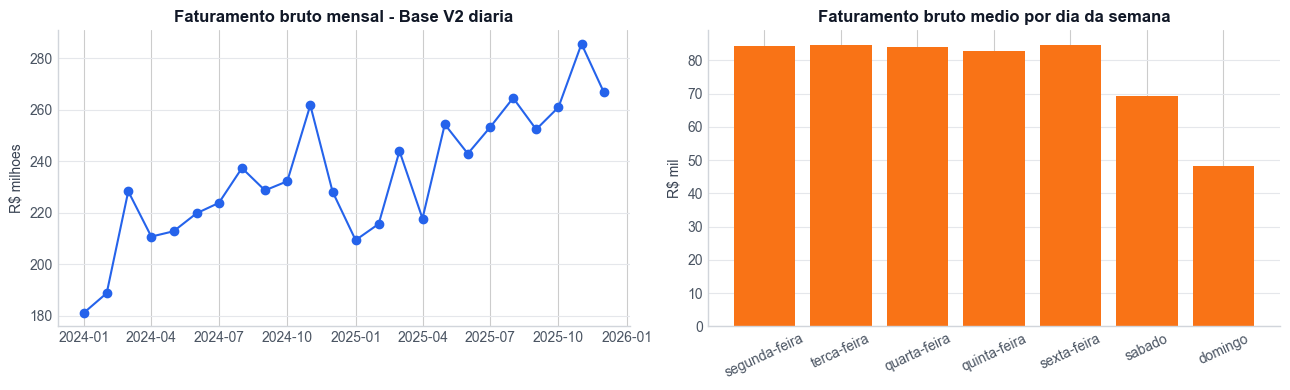

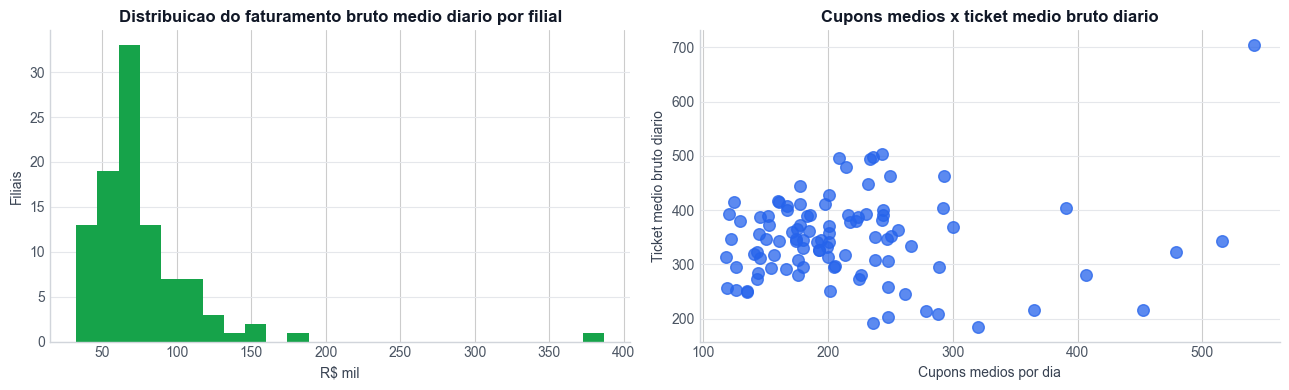

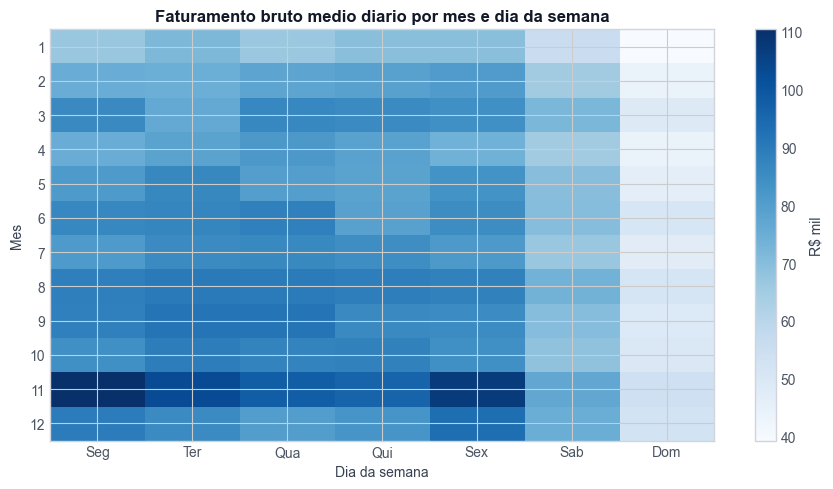

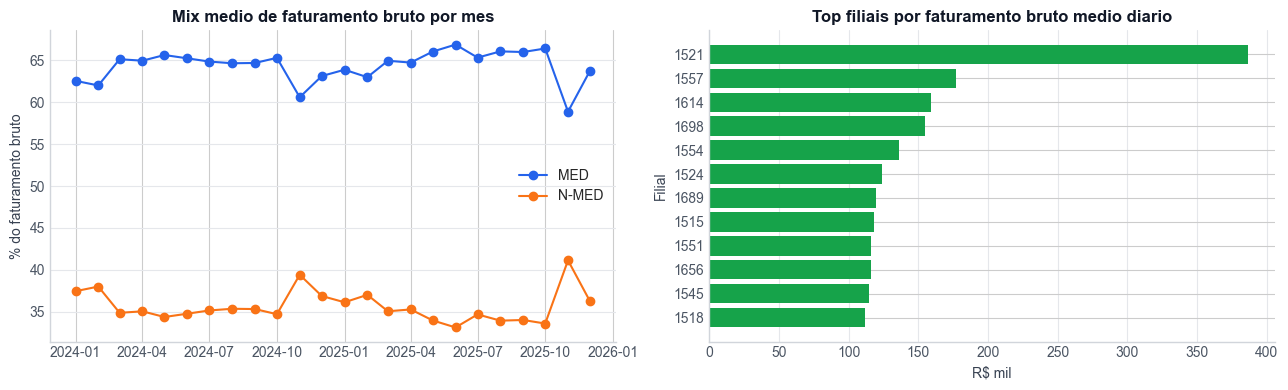

,checkpoint_salvo
features_diarias,E:\trabalhos\PROJ3- Panvel\Base_V2\features_fi...
features_agregadas,E:\trabalhos\PROJ3- Panvel\Base_V2\features_fi...


In [9]:
validacao = validar_chaves(features_diarias, features_agregadas)
display(validacao)

plotar_resumo_base_v2(features_diarias, features_agregadas)
plotar_visualizacoes_complementares(features_diarias, features_agregadas)

caminhos_salvos = salvar_checkpoints_v2(features_diarias, features_agregadas)
display(pd.Series(caminhos_salvos, name="checkpoint_salvo").to_frame())
